In [2]:
import sys
print(sys.executable)
import pandas as pd
print(pandas.__version__)

/Users/iketanimotoki/Desktop/練習場/PracticeFDev/PyData_train/.venv/bin/python


NameError: name 'pandas' is not defined

In [3]:
import sys
print(sys.executable)
import pandas as pd
print(pd.__version__)

/Users/iketanimotoki/Desktop/練習場/PracticeFDev/PyData_train/.venv/bin/python
3.0.3


In [5]:
import pandas as pd

In [8]:
df_train = pd.read_csv("./data/tamed/tamed_1.csv")
df_train.head(20)

,年月日,平均気温(℃),最高気温(℃),最低気温(℃)
0,2025/1/1,5.9,12.1,1.9
1,2025/1/2,6.2,12.3,1.1
2,2025/1/3,6.4,11.0,3.5
3,2025/1/4,5.0,9.1,2.6
4,2025/1/5,4.6,10.0,0.1
5,2025/1/6,6.1,8.0,3.6
6,2025/1/7,5.4,9.3,1.9
7,2025/1/8,3.4,8.0,0.3
8,2025/1/9,2.7,8.0,-0.6
9,2025/1/10,1.1,4.7,-2.0


In [11]:
df_train.shape

(365, 4)

In [12]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   年月日      365 non-null    str    
 1   平均気温(℃)  365 non-null    float64
 2   最高気温(℃)  365 non-null    float64
 3   最低気温(℃)  365 non-null    float64
dtypes: float64(3), str(1)
memory usage: 11.5 KB


In [13]:
df_train.describe()

,平均気温(℃),最高気温(℃),最低気温(℃)
count,365.000000,365.000000,365.000000
mean,17.560000,22.601918,13.538356
std,9.491771,9.910031,9.493703
min,-0.200000,4.000000,-3.400000
25%,8.700000,13.500000,4.900000
50%,17.000000,22.600000,12.200000
75%,26.900000,31.300000,23.200000
max,32.900000,39.600000,29.300000


## 時系列予測

整理済みデータの平均気温を日次系列として扱い、最後の30日をホールドアウトしてベースラインとSARIMAXを比較します。

抽出後のカラム:
['年月日', '平均気温(℃)', '最高気温(℃)', '最低気温(℃)']
変換後のデータの最初の3行は
        年月日 平均気温(℃)       date  temp_avg
0  2025/1/1     5.9 2025-01-01       5.9
1  2025/1/2     6.2 2025-01-02       6.2
2  2025/1/3     6.4 2025-01-03       6.4
data shape: (365,)
train/test: 335 / 30
seasonal naive -> MAE=3.857, RMSE=4.316
Fourier OLS -> MAE=2.619, RMSE=3.402
                            OLS Regression Results                            
Dep. Variable:               temp_avg   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     1005.
Date:                Mon, 01 Jun 2026   Prob (F-statistic):          7.21e-197
Time:                        16:39:13   Log-Likelihood:                -759.19
No. Observations:                 335   AIC:                             1530.
Df Residuals:                     329   BIC:                             1553.
Df Model:             

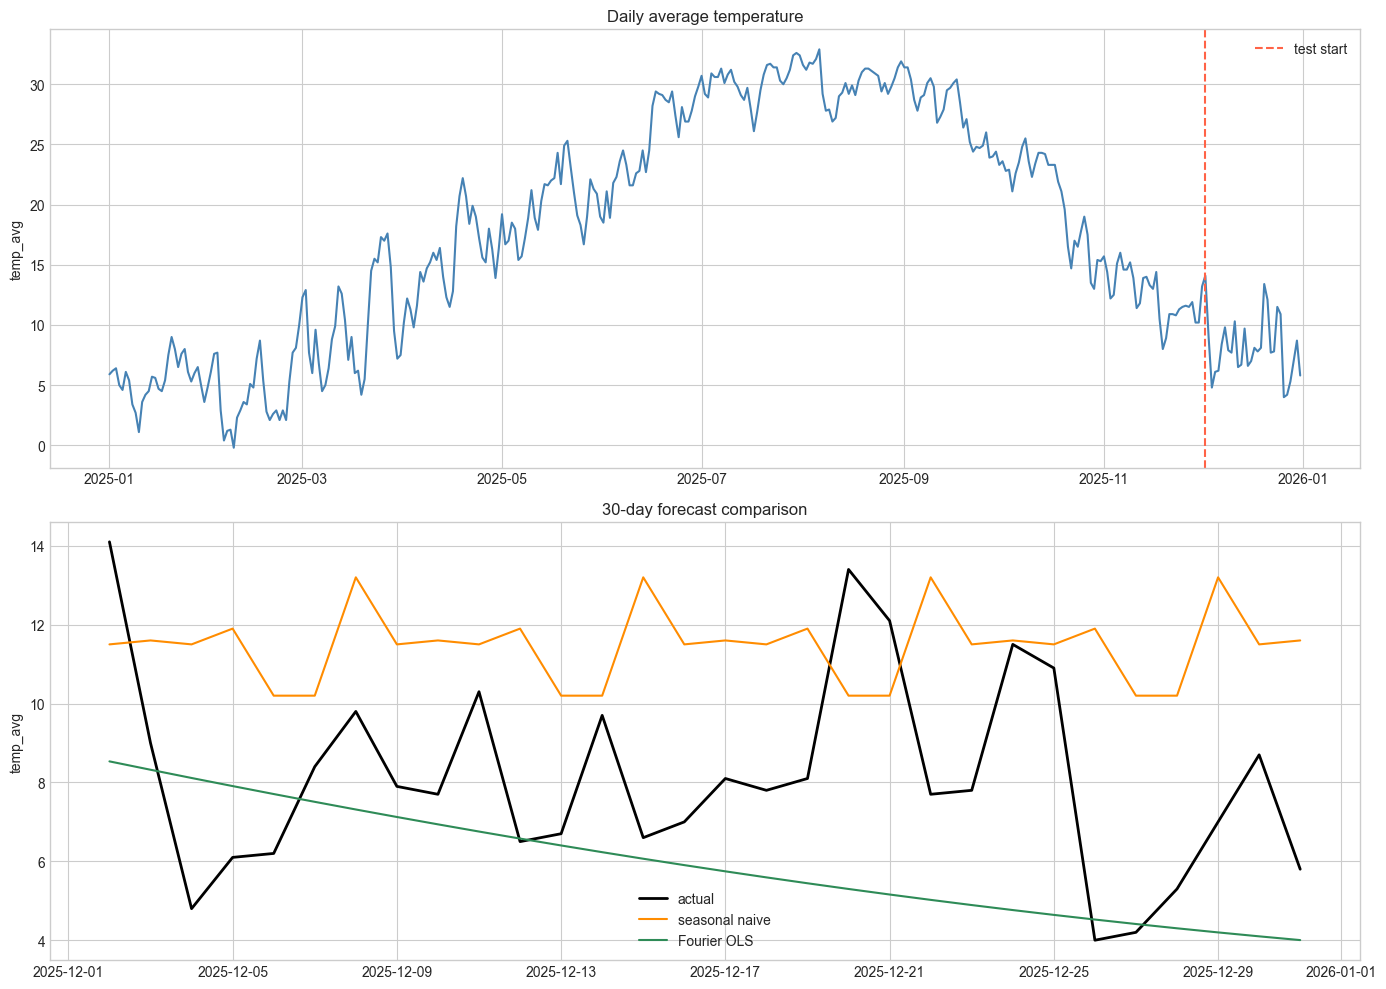

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error

from src.extract import extract_data
from src.transfform import transform_data

plt.style.use("seaborn-v0_8-whitegrid")

raw_path = Path("data/raw/data.csv")
df = transform_data(extract_data(raw_path))

series = (
    df.set_index("date")["temp_avg"]
    .asfreq("D")
    .astype(float)
    .interpolate(method="time")
)

train_size = len(series) - 30
train = series.iloc[:train_size]
test = series.iloc[train_size:]

season_length = 7
seasonal_naive = np.tile(train.iloc[-season_length:].to_numpy(), int(np.ceil(len(test) / season_length)))[: len(test)]


def make_features(index, offset=0):
    day_of_year = index.dayofyear.to_numpy()
    trend = np.arange(offset, offset + len(index))
    return pd.DataFrame(
        {
            "trend": trend,
            "sin1": np.sin(2 * np.pi * day_of_year / 365.25),
            "cos1": np.cos(2 * np.pi * day_of_year / 365.25),
            "sin2": np.sin(4 * np.pi * day_of_year / 365.25),
            "cos2": np.cos(4 * np.pi * day_of_year / 365.25),
        },
        index=index,
    )


x_train = sm.add_constant(make_features(train.index), has_constant="add")
x_test = sm.add_constant(make_features(test.index, offset=len(train)), has_constant="add")
fourier_model = sm.OLS(train, x_train).fit()
fourier_forecast = fourier_model.predict(x_test)


def score(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse


naive_mae, naive_rmse = score(test, seasonal_naive)
fourier_mae, fourier_rmse = score(test, fourier_forecast)

print(f"data shape: {series.shape}")
print(f"train/test: {train.shape[0]} / {test.shape[0]}")
print(f"seasonal naive -> MAE={naive_mae:.3f}, RMSE={naive_rmse:.3f}")
print(f"Fourier OLS -> MAE={fourier_mae:.3f}, RMSE={fourier_rmse:.3f}")
print(fourier_model.summary())

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

axes[0].plot(series.index, series, color="steelblue", linewidth=1.5)
axes[0].axvline(test.index[0], color="tomato", linestyle="--", label="test start")
axes[0].set_title("Daily average temperature")
axes[0].set_ylabel("temp_avg")
axes[0].legend()

axes[1].plot(test.index, test, label="actual", color="black", linewidth=2)
axes[1].plot(test.index, seasonal_naive, label="seasonal naive", color="darkorange")
axes[1].plot(test.index, fourier_forecast, label="Fourier OLS", color="seagreen")
axes[1].set_title("30-day forecast comparison")
axes[1].set_ylabel("temp_avg")
axes[1].legend()

plt.tight_layout()
plt.show()